In [1]:
from ipywidgets import widgets
from math import floor
from numpy import floating
from numpy._typing import _32Bit
from prometheus_client.decorator import append
from random import random
from typing import Tuple, override
from scipy.signal import savgol_filter
from scipy import signal
from scipy.spatial.distance import cosine
import math

from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation

import numpy as np
from numpy.typing import NDArray

from scipy.signal import argrelextrema
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import Span

from typing import Annotated, Literal

from annotated_types import Gt

from pydantic import BaseModel
import pydantic_numpy.typing as pnd
from pydantic_numpy import np_array_pydantic_annotated_typing
from pydantic_numpy.model import NumpyModel, MultiArrayNumpyFile

from typing import List, Tuple, Dict

In [2]:


from extract_packets import extract_data, plot_eye_cmp

In [3]:
extracted_packets = extract_data()

In [12]:



def get_phase_data_for_packet(samples) -> \
        (
                np.complex64, np.complex64, np.complex64, np.complex64, np.complex64, np.complex64, np.complex64,
                np.complex64,
                np.complex64, np.complex64, np.complex64,
        ) \
        :
    q1_data = I1Q1 = np.average(np.array([x for x in samples if np.real(x) > 0 and np.imag(x) > 0]))
    q2_data = I1Qn1 = np.average(np.array([x for x in samples if np.real(x) > 0 > np.imag(x)]))
    q3_data = In1Qn1 = np.average(np.array([x for x in samples if np.real(x) < 0 and np.imag(x) < 0]))
    q4_data = In1Q1 = np.average(np.array([x for x in samples if np.real(x) < 0 < np.imag(x)]))

    q1_ideal = np.complex64(1, 1)
    q2_ideal = np.complex64(1, -1)
    q3_ideal = np.complex64(-1, -1)
    q4_ideal = np.complex64(-1, 1)

    q1_magnitude_diff = np.abs(q1_data) - np.abs(q1_ideal)
    q2_magnitude_diff = np.abs(q2_data) - np.abs(q2_ideal)
    q3_magnitude_diff = np.abs(q3_data) - np.abs(q3_ideal)
    q4_magnitude_diff = np.abs(q4_data) - np.abs(q4_ideal)

    q1_angle_diff = np.angle(q1_data) - np.angle(q1_ideal)
    q2_angle_diff = np.angle(q2_data) - np.angle(q2_ideal)
    q3_angle_diff = np.angle(q3_data) - np.angle(q3_ideal)
    q4_angle_diff = np.angle(q4_data) - np.angle(q4_ideal)

    center_point = np.average([q1_data, q2_data, q3_data, q4_data], axis=0)
    average_magnitude_diff = np.average([q1_magnitude_diff, q2_magnitude_diff, q3_magnitude_diff, q4_magnitude_diff])
    average_angle_diff = np.average([q1_angle_diff, q2_angle_diff, q3_angle_diff, q4_angle_diff])

    return (
        average_angle_diff,
        average_magnitude_diff,
        center_point,
        q1_magnitude_diff,
        q2_magnitude_diff,
        q3_magnitude_diff,
        q4_magnitude_diff,
        q1_angle_diff,
        q2_angle_diff,
        q3_angle_diff,
        q4_angle_diff,
    )

In [15]:
def get_data_map(extracted_data_from_packet):
    valid, _, (samples_time,
               frequency_offset,
               avg_phase_shift,
               time_offset,
               phase_ambiguity,
               avg_time_error
               ) = extracted_data_from_packet
    (
        average_angle_diff,
        average_magnitude_diff,
        center_point,
        q1_magnitude_diff,
        q2_magnitude_diff,
        q3_magnitude_diff,
        q4_magnitude_diff,
        q1_angle_diff,
        q2_angle_diff,
        q3_angle_diff,
        q4_angle_diff,
    ) = get_phase_data_for_packet(samples_time)

    return {
        'frequency_offset': frequency_offset,
        'avg_phase_shift': avg_phase_shift,
        'time_offset': time_offset,
        'phase_ambiguity': phase_ambiguity,
        'avg_time_error': avg_time_error,
        'average_angle_diff': average_angle_diff,
        'average_magnitude_diff': average_magnitude_diff,
        'center_point': center_point,
        'q1_magnitude_diff': q1_magnitude_diff,
        'q2_magnitude_diff': q2_magnitude_diff,
        'q3_magnitude_diff': q3_magnitude_diff,
        'q4_magnitude_diff': q4_magnitude_diff,
        'q1_angle_diff': q1_angle_diff,
        'q2_angle_diff': q2_angle_diff,
        'q3_angle_diff': q3_angle_diff,
        'q4_angle_diff': q4_angle_diff,
    }



In [16]:
import pandas as pd

pd.DataFrame([get_data_map(packet) for packet in extracted_packets])    

,frequency_offset,avg_phase_shift,time_offset,phase_ambiguity,avg_time_error,average_angle_diff,average_magnitude_diff,center_point,q1_magnitude_diff,q2_magnitude_diff,q3_magnitude_diff,q4_magnitude_diff,q1_angle_diff,q2_angle_diff,q3_angle_diff,q4_angle_diff
0,26804.091797,0.490874,-20,0.000000,0.618333,-0.005875,0.165278,0.002243-0.002365j,0.120018,0.209389,0.123884,0.207822,-0.006009,-0.008369,0.001441,-0.010564
1,26781.734375,0.981748,-20,0.000000,0.240056,-0.017569,0.215108,-0.005927-0.001554j,0.162118,0.258873,0.180421,0.259021,-0.009777,-0.022509,-0.017290,-0.020701
2,26780.742188,1.079922,-21,4.712389,0.847528,0.012444,0.156877,0.006485+0.011660j,0.134302,0.187513,0.108225,0.197466,0.001294,0.032850,-0.001346,0.016978
3,26790.904297,1.276272,-25,1.570796,0.489490,-0.013122,0.133564,0.000040-0.007705j,0.106063,0.134468,0.155549,0.138175,-0.020336,-0.005212,-0.003633,-0.023308
4,26801.052734,1.276272,-20,3.141593,0.582574,-0.020170,0.161005,0.004007+0.002578j,0.124864,0.196832,0.124632,0.197693,-0.020002,-0.016071,-0.017079,-0.027528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
416,26788.242188,1.472622,-21,4.712389,0.871521,-0.014445,0.165067,-0.000572+0.000378j,0.122190,0.208952,0.146806,0.182320,-0.002045,-0.009824,-0.021062,-0.024848
417,26755.662109,1.374447,-20,1.570796,0.800448,-0.003399,0.140284,-0.003298-0.000645j,0.106832,0.157154,0.135894,0.161257,-0.005799,0.005727,-0.007882,-0.005641
418,26782.615234,1.178097,-20,3.141593,0.643744,-0.026362,0.158858,0.002910-0.007091j,0.102438,0.205168,0.141486,0.186341,-0.019858,-0.027121,-0.013916,-0.044552
419,26775.646484,1.178097,-22,1.570796,0.543200,-0.004282,0.146660,-0.009270-0.002137j,0.109871,0.145150,0.153284,0.178335,-0.015582,0.006255,-0.006832,-0.000969


In [5]:
I1Q1 = np.array([x for x in samples_time if np.real(x) > 0 and np.imag(x) > 0])
In1Qn1 = np.array([x for x in samples_time if np.real(x) < 0 and np.imag(x) < 0])
I1Qn1 = np.array([x for x in samples_time if np.real(x) > 0 > np.imag(x)])
In1Q1 = np.array([x for x in samples_time if np.real(x) < 0 < np.imag(x)])

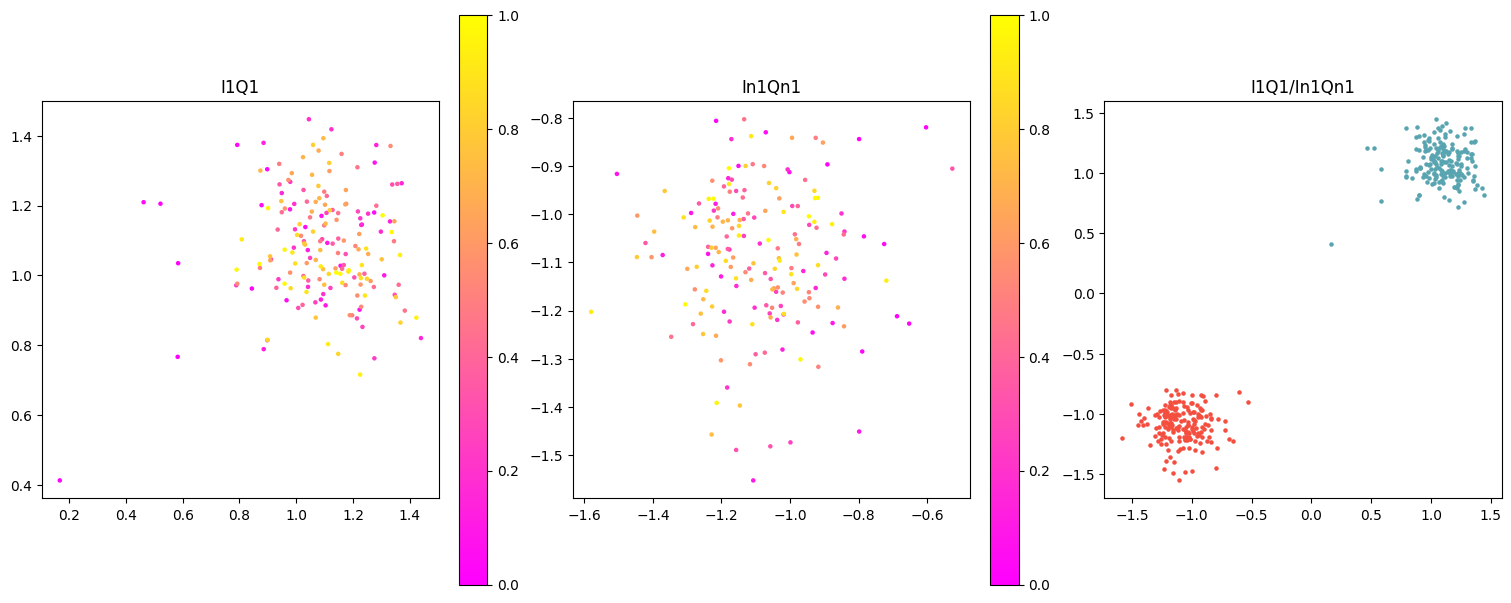

In [6]:
plot_eye_cmp(I1Q1, In1Qn1, samples_per_symbol=4, s1_title='I1Q1',
             s2_title='In1Qn1', disable_combo=False)

1.5855101
736


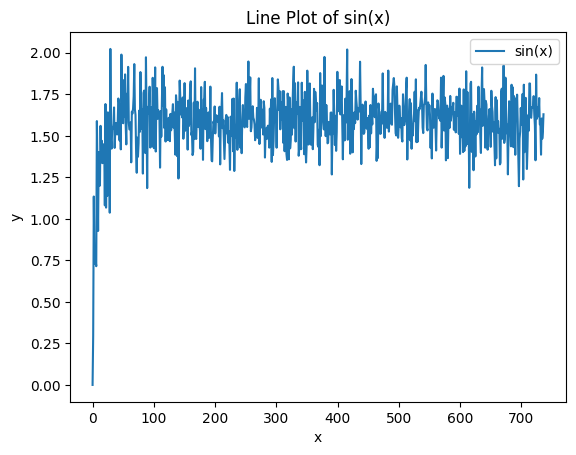

In [7]:

data = samples_time
# data=samples_time[0:16*46+1]
# Plot the data using Matplotlib
plt.plot(np.linspace(0, len(data), len(data)), np.abs(data), label='sin(x)')

avg = np.average(np.abs(data))
print(avg)
print(len(data))
# plt.plot(np.linspace(0, len(data), len(data)), np.abs(data), label='sin(x)')


plt.xlabel('x')
plt.ylabel('y')
plt.title('Line Plot of sin(x)')
plt.legend()
plt.show()